# PIAB3D — Three-dimensional particle in a rectangular box

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>

## Question

How does three-dimensional Cartesian confinement organize energies, degeneracies, and spatial structure?

## Learning objectives

- Construct normalized three-dimensional product states.
- Build the sparse 3D kinetic matrix and solve for low eigenpairs.
- Compare cubic and generic orthorhombic degeneracy.
- Check matrix eigenvalues and eigenvectors, then visualize bounded slices.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This completes Cartesian hard-wall confinement before periodic cells are introduced.


## Model and analytical solution

For a rectangular cuboid with side lengths $L_x,L_y,L_z$,

$$
\psi_{n_xn_yn_z}=\sqrt{\frac{8}{L_xL_yL_z}}
\prod_{i\in\{x,y,z\}}\sin\!\left(\frac{n_i\pi x_i}{L_i}\right),
$$

$$
E_{n_xn_yn_z}=\pi^2\left(
\frac{n_x^2}{L_x^2}+\frac{n_y^2}{L_y^2}+\frac{n_z^2}{L_z^2}
\right)
$$

in the accepted reduced units.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.sparse.linalg import eigsh
np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
Lx = Ly = Lz = 1.0
x = np.linspace(0.0, Lx, 61)
y = np.linspace(0.0, Ly, 61)
z = np.linspace(0.0, Lz, 61)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")


def psi3(nx, ny, nz):
    prefactor = np.sqrt(8.0 / (Lx * Ly * Lz))
    return (prefactor
            * np.sin(nx * np.pi * X / Lx)
            * np.sin(ny * np.pi * Y / Ly)
            * np.sin(nz * np.pi * Z / Lz))


quantum_numbers = (1, 2, 3)
state = psi3(*quantum_numbers)
energy = np.pi**2 * sum(n**2 for n in quantum_numbers)
assert state.shape == (len(x), len(y), len(z))
assert np.issubdtype(state.dtype, np.floating)
norm_z = np.trapezoid(np.abs(state) ** 2, x=z, axis=2)
norm_yz = np.trapezoid(norm_z, x=y, axis=1)
norm = np.trapezoid(norm_yz, x=x)
assert np.isclose(norm, 1.0, rtol=1e-10, atol=1e-12)
for axis in range(3):
    assert np.allclose(np.take(state, [0, -1], axis=axis), 0.0, atol=1e-12)
print("quantum numbers:", quantum_numbers)
print(f"reduced energy={energy:.6f}, sampled volume norm={norm:.12f}")
print("state array shape:", state.shape)


quantum numbers: (1, 2, 3)
reduced energy=138.174462, sampled volume norm=1.000000000000
state array shape: (61, 61, 61)


## Matrix eigenproblem

The three-dimensional Dirichlet kinetic matrix is the sparse Kronecker sum

$$
T_h=T_x\otimes I_y\otimes I_z
+I_x\otimes T_y\otimes I_z
+I_x\otimes I_y\otimes T_z.
$$

The construction follows `indexing="ij"` and C-order flattening, so $z$ varies
fastest. Only six low eigenpairs are requested from the sparse Hermitian solver.


In [3]:
interior_shape = (9, 9, 9)
spacings = np.array([Lx, Ly, Lz]) / (np.asarray(interior_shape) + 1)

def dirichlet_kinetic(count, spacing):
    return sparse.diags(
        (-np.ones(count - 1), 2.0 * np.ones(count), -np.ones(count - 1)),
        offsets=(-1, 0, 1), format="csr"
    ) / spacing**2

operators = [dirichlet_kinetic(count, spacing)
             for count, spacing in zip(interior_shape, spacings)]
identities = [sparse.identity(count, format="csr") for count in interior_shape]
kinetic_matrix = (
    sparse.kron(sparse.kron(operators[0], identities[1]), identities[2], format="csr")
    + sparse.kron(sparse.kron(identities[0], operators[1]), identities[2], format="csr")
    + sparse.kron(sparse.kron(identities[0], identities[1]), operators[2], format="csr")
)
eigenvalues, eigenvectors = eigsh(
    kinetic_matrix, k=6, which="SA", v0=np.ones(kinetic_matrix.shape[0])
)
order = np.argsort(eigenvalues)
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
one_dimensional_energies = [
    4.0 / spacing**2 * np.sin(np.arange(1, count + 1) * np.pi / (2 * (count + 1))) ** 2
    for count, spacing in zip(interior_shape, spacings)
]
discrete_reference = np.sort((
    one_dimensional_energies[0][:, None, None]
    + one_dimensional_energies[1][None, :, None]
    + one_dimensional_energies[2][None, None, :]
).ravel())[:6]
residuals = np.array([
    np.linalg.norm(kinetic_matrix @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(eigenvalues)
])
interior_axes = [np.arange(1, count + 1) * spacing
                 for count, spacing in zip(interior_shape, spacings)]
Xi, Yi, Zi = np.meshgrid(*interior_axes, indexing="ij")
numerical_ground = eigenvectors[:, 0].reshape(interior_shape, order="C") / np.sqrt(np.prod(spacings))
analytical_ground = (np.sqrt(8.0 / (Lx * Ly * Lz))
                     * np.sin(np.pi * Xi / Lx)
                     * np.sin(np.pi * Yi / Ly)
                     * np.sin(np.pi * Zi / Lz))
if np.vdot(numerical_ground, analytical_ground).real < 0.0:
    numerical_ground *= -1.0
assert kinetic_matrix.shape == (np.prod(interior_shape),) * 2
assert np.issubdtype(kinetic_matrix.dtype, np.floating)
assert np.allclose(eigenvalues, discrete_reference, rtol=1e-10, atol=1e-12)
assert np.allclose(numerical_ground, analytical_ground, rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
print("kinetic matrix shape, nnz, dtype:", kinetic_matrix.shape, kinetic_matrix.nnz, kinetic_matrix.dtype)
print("lowest matrix eigenvalues:", eigenvalues)
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


kinetic matrix shape, nnz, dtype: (729, 729) 4617 float64
lowest matrix eigenvalues: [29.36609  57.773995 57.773995 57.773995 86.181899 86.181899]
eigensolver residual bound satisfied: True


In [4]:
triples = [(i, j, k) for i in range(1, 4) for j in range(1, 4) for k in range(1, 4)]
groups = {}
for values in triples:
    groups.setdefault(sum(value**2 for value in values), []).append(values)
degenerate = {value: members for value, members in groups.items() if len(members) > 1}
print("selected cubic degeneracy groups:")
for value, members in sorted(degenerate.items())[:5]:
    print(value, members)

lengths = np.array([1.0, 1.2, 1.4])
def rectangular_energy(numbers):
    return np.pi**2 * np.sum((np.asarray(numbers) / lengths) ** 2)
assert not np.isclose(rectangular_energy((1, 2, 3)), rectangular_energy((3, 2, 1)))


selected cubic degeneracy groups:
6 [(1, 1, 2), (1, 2, 1), (2, 1, 1)]
9 [(1, 2, 2), (2, 1, 2), (2, 2, 1)]
11 [(1, 1, 3), (1, 3, 1), (3, 1, 1)]
14 [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]
17 [(2, 2, 3), (2, 3, 2), (3, 2, 2)]


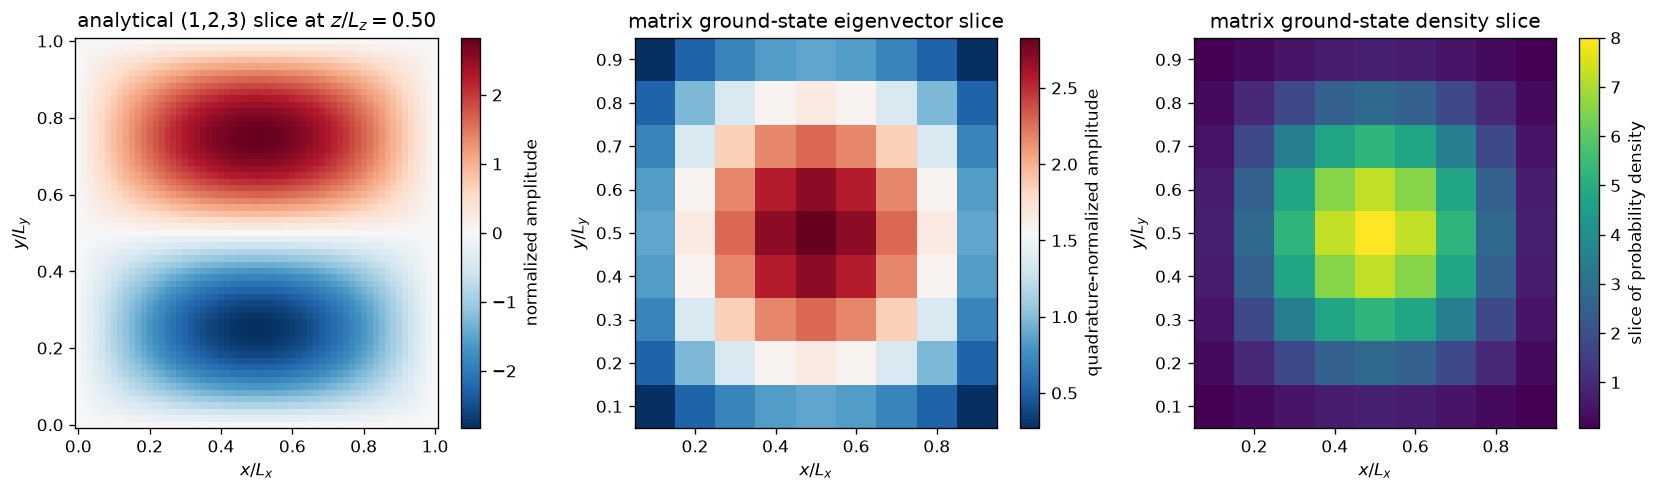

In [5]:
mid_z = len(z) // 2
mid_z_numerical = interior_shape[2] // 2
slice_xy = state[:, :, mid_z]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
image0 = axes[0].pcolormesh(X[:, :, mid_z], Y[:, :, mid_z], slice_xy, shading="auto", cmap="RdBu_r")
image1 = axes[1].pcolormesh(Xi[:, :, mid_z_numerical], Yi[:, :, mid_z_numerical],
                            numerical_ground[:, :, mid_z_numerical], shading="auto", cmap="RdBu_r")
image2 = axes[2].pcolormesh(Xi[:, :, mid_z_numerical], Yi[:, :, mid_z_numerical],
                            np.abs(numerical_ground[:, :, mid_z_numerical]) ** 2,
                            shading="auto", cmap="viridis")
axes[0].set(title=fr"analytical (1,2,3) slice at $z/L_z={z[mid_z]:.2f}$", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
axes[1].set(title="matrix ground-state eigenvector slice", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
axes[2].set(title="matrix ground-state density slice", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
fig.colorbar(image0, ax=axes[0], label="normalized amplitude")
fig.colorbar(image1, ax=axes[1], label="quadrature-normalized amplitude")
fig.colorbar(image2, ax=axes[2], label="slice of probability density")
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The sparse matrix is a bounded finite-difference representation, not continuum-convergence evidence. A slice is only a view of the 3D eigenvector, and the ideal cuboid is not a material model.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

PBC1D replaces hard walls with Born–von Kármán identification in a solid-state unit cell.
